# Credit Card Fraud Detection System

## Objective

The goal of this project is to build a machine learning-based Fraud Detection System capable of identifying fraudulent credit card transactions.

Fraud detection is a highly imbalanced classification problem because fraudulent transactions represent only a very small fraction of all transactions. Traditional accuracy metrics can therefore be misleading.

This project uses Exploratory Data Analysis (EDA), Data Preprocessing, SMOTE oversampling, and multiple Machine Learning algorithms to detect fraud effectively.

### Models Used

* Isolation Forest (Anomaly Detection)
* Random Forest Classifier
* XGBoost Classifier

### Evaluation Metrics

* Precision
* Recall
* F1-Score
* ROC-AUC Score
* Precision-Recall Curve

The final objective is to compare multiple approaches and identify the most effective model for fraud detection.


In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Settings
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

**STAGE 1 - DATA LOADING & OVERVIEW**

**Purpose**

Before building any machine learning model, it is important to understand the dataset.

In this stage we:

* Load the Credit Card Fraud dataset
* Examine dataset dimensions
* Check data types
* Detect missing values
* Identify duplicate records
* Review statistical summaries
* Analyze fraud and legitimate transaction distribution

Understanding the data helps identify potential quality issues and guides later preprocessing decisions.


In [2]:
# Load dataset

df = pd.read_csv("creditcard.csv")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n")

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

DATASET SHAPE
(284807, 31)


DATA TYPES
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


FIRST 5 ROWS
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -

In [3]:
#Missing Values & Duplicates

print("="*60)
print("NULL VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("DUPLICATES")
print("="*60)
print("Duplicate Rows :", df.duplicated().sum())

NULL VALUES
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


DUPLICATES
Duplicate Rows : 1081


In [4]:
#Descriptive Statistics

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())

DESCRIPTIVE STATISTICS
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00

In [5]:
#Class Distribution

print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_dist = df["Class"].value_counts()

print(class_dist)

fraud_percentage = (
    class_dist[1] / len(df)
) * 100

print(f"\nFraud Percentage: {fraud_percentage:.4f}%")

CLASS DISTRIBUTION
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


**STAGE 2 - EXPLORATORY DATA ANALYSIS (EDA)**

**Purpose**

Exploratory Data Analysis helps uncover hidden patterns, trends, and relationships within the data.

The analysis focuses on:

* Distribution of fraudulent and legitimate transactions
* Transaction amount behavior
* Transaction time patterns
* Correlation among variables
* Features most associated with fraudulent activity

These insights help us understand the characteristics of fraud and identify important predictors for model training.


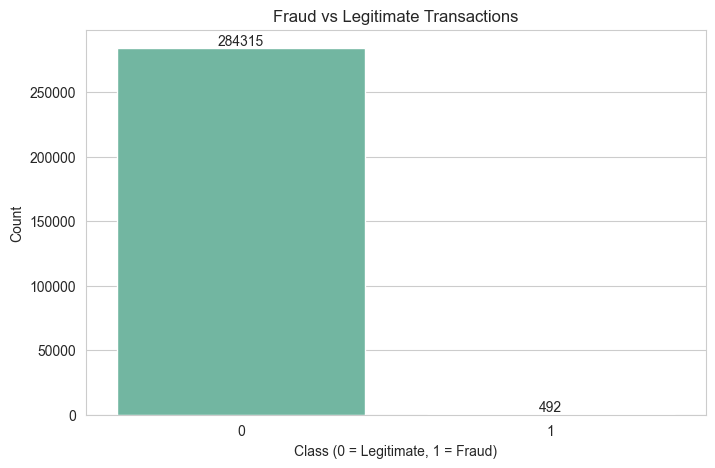

Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [6]:
#Fraud vs Legitimate Transactions

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Class',
    hue='Class',
    data=df,
    palette='Set2',
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

print(df['Class'].value_counts())

print("\nPercentage Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

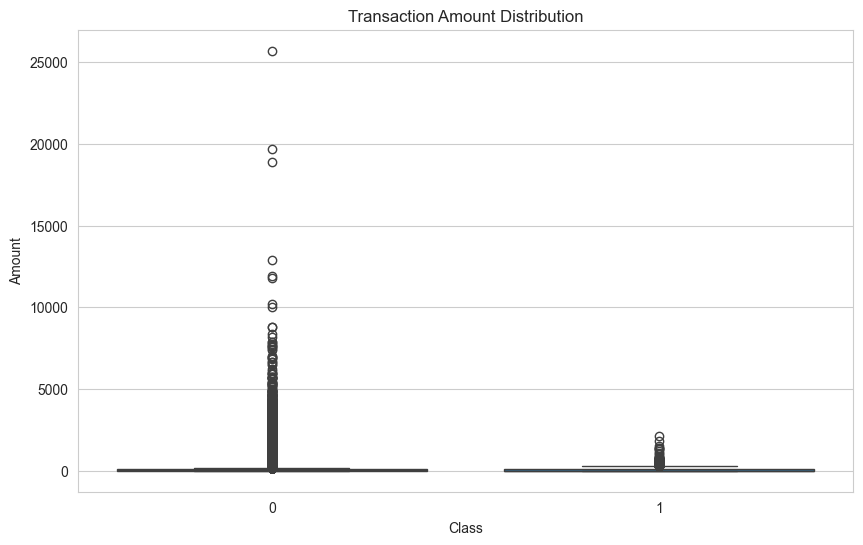

In [7]:
#Amount Distribution

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

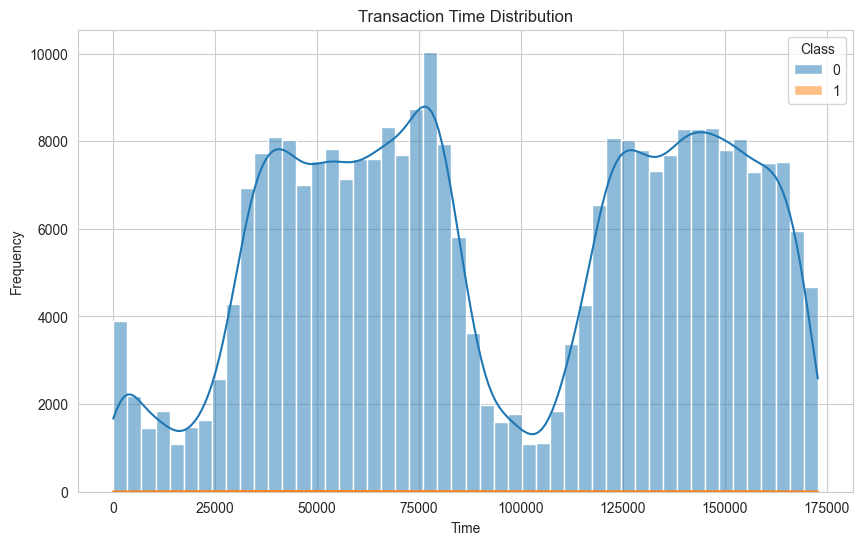

In [8]:
#Time Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Time',
    hue='Class',
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

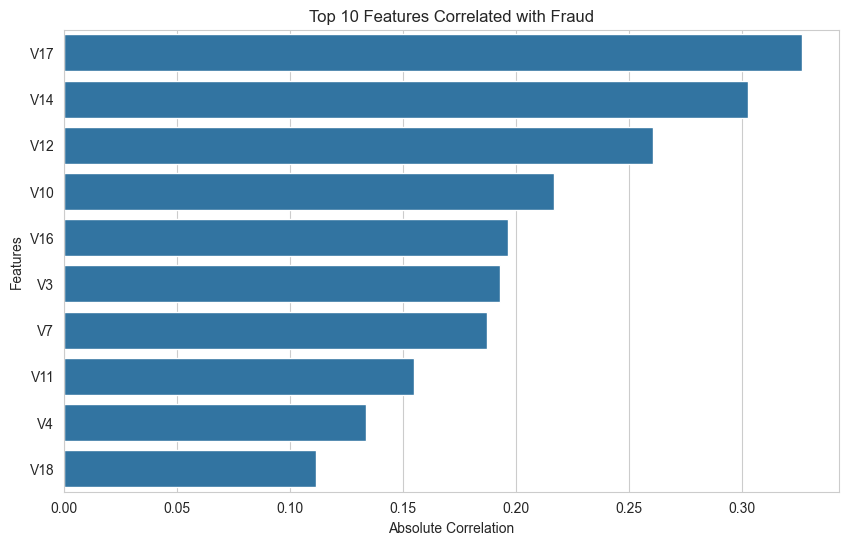

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [9]:
#Top 10 Features Correlated with Fraud

# Compute correlation directly without plotting full heatmap

corr_matrix = df.corr()

fraud_corr = corr_matrix["Class"].drop("Class")

top_features = (
    fraud_corr.abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 10 Features Correlated with Fraud")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")

plt.show()

print(top_features)

**STAGE 3 - DATA PREPROCESSING**

**Purpose**

Raw data cannot be directly used for machine learning.

In this stage we prepare the data by:

- Removing duplicate records
- Separating features and target variable
- Splitting data into training and testing sets
- Handling class imbalance using SMOTE
- Scaling numerical variables

Special care is taken to avoid data leakage by applying SMOTE only on the training dataset.

The resulting dataset is ready for model training.

In [10]:
#Remove Duplicates

print("Before Removing Duplicates :", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates :", df.shape)

Before Removing Duplicates : (284807, 31)
After Removing Duplicates : (283726, 31)


In [11]:
#Split Features & Target

X = df.drop("Class", axis=1)
y = df["Class"]

In [12]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (226980, 30)
Testing Shape : (56746, 30)


In [13]:
#Class Distribution Before SMOTE

print("="*60)
print("BEFORE SMOTE")
print("="*60)

print(y_train.value_counts())

BEFORE SMOTE
Class
0    226602
1       378
Name: count, dtype: int64


In [14]:
#Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("="*60)
print("AFTER SMOTE")
print("="*60)

print(y_train_smote.value_counts())

AFTER SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


In [15]:
#Scale Amount and Time

scaler = StandardScaler()

X_train_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

# Scale only Amount and Time

X_train_scaled[['Amount','Time']] = scaler.fit_transform(
    X_train_scaled[['Amount','Time']]
)

X_test_scaled[['Amount','Time']] = scaler.transform(
    X_test_scaled[['Amount','Time']]
)

print("Scaling Complete")

Scaling Complete


**STAGE 4 - MODEL BUILDING & TRAINING**

**Purpose**

The objective of this stage is to train multiple fraud detection models and compare their performance.

Three different approaches are used:

**1. Isolation Forest**
An unsupervised anomaly detection algorithm that identifies unusual transaction patterns.

**2. Random Forest**
A supervised ensemble learning method that uses multiple decision trees for classification.

**3. XGBoost**
A powerful gradient boosting algorithm known for excellent performance on structured datasets.

Training multiple models enables a comprehensive comparison of fraud detection strategies.

In [16]:
#1. Isolation Forest

iso_forest = IsolationForest(
    contamination=0.002,
    random_state=42
)

iso_forest.fit(X_train_scaled)

iso_pred = iso_forest.predict(X_test_scaled)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

iso_scores = -iso_forest.decision_function(
    X_test_scaled
)

In [17]:
#2. Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train_smote
)

rf_pred = rf_model.predict(
    X_test_scaled
)

rf_prob = rf_model.predict_proba(
    X_test_scaled
)[:,1]

In [18]:
#3. XGBoost

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_scaled,
    y_train_smote
)

xgb_pred = xgb_model.predict(
    X_test_scaled
)

xgb_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

**STAGE 5 - MODEL EVALUATION**

**Purpose**

Model evaluation helps determine how effectively each algorithm detects fraudulent transactions.

The following metrics are used:

- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

Because fraud detection datasets are highly imbalanced, F1-Score and ROC-AUC are considered more informative than accuracy alone.

ROC Curves and Precision-Recall Curves are also generated to visually compare model performance.

In [19]:
#Evaluation Function

results = []

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    print("\n")
    print("="*70)
    print(model_name)
    print("="*70)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("ROC-AUC :", roc_auc)
    print("F1 Score :", f1)



Isolation Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



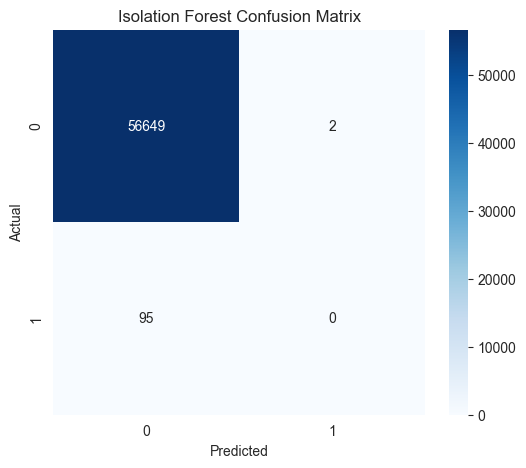

ROC-AUC : 0.8071484778918754
F1 Score : 0.0


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



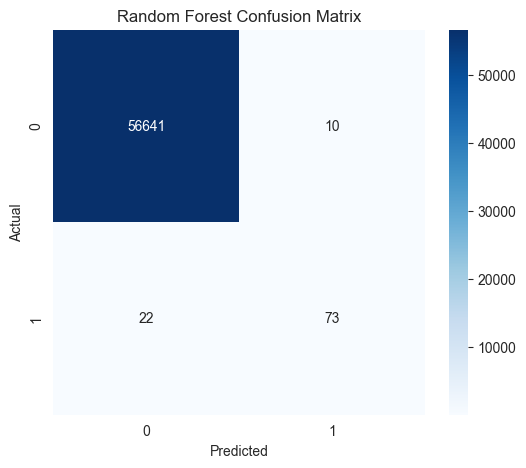

ROC-AUC : 0.9690088622024603
F1 Score : 0.8202247191011236


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.80      0.82        95

    accuracy                           1.00     56746
   macro avg       0.92      0.90      0.91     56746
weighted avg       1.00      1.00      1.00     56746



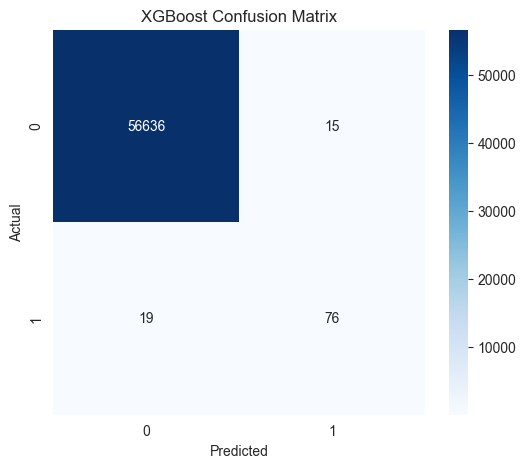

ROC-AUC : 0.9659856424701938
F1 Score : 0.8172043010752689


In [20]:
#Evaluate Models

evaluate_model(
    "Isolation Forest",
    y_test,
    iso_pred,
    iso_scores
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

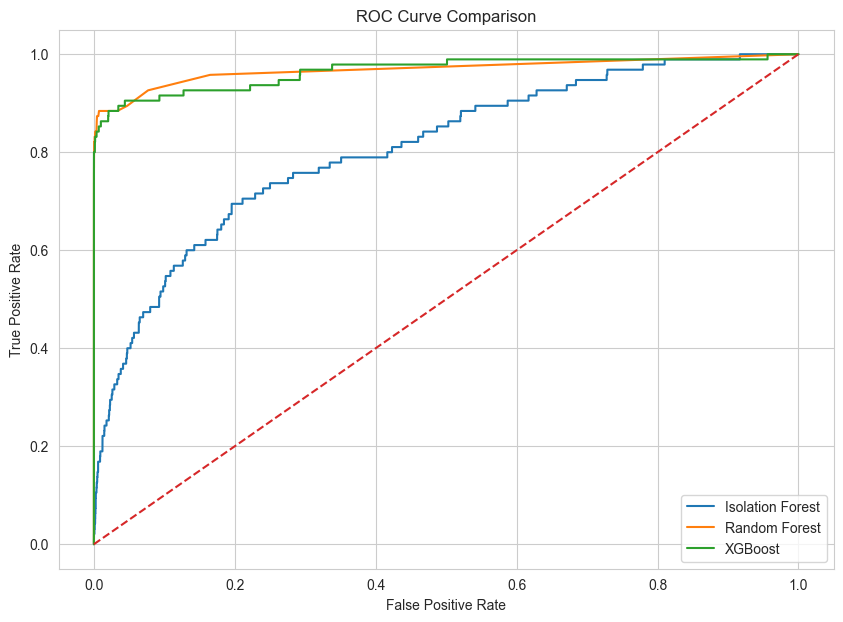

In [21]:
#ROC Curve Comparison

plt.figure(figsize=(10,7))

fpr_iso, tpr_iso, _ = roc_curve(
    y_test,
    iso_scores
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.plot(
    fpr_iso,
    tpr_iso,
    label='Isolation Forest'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

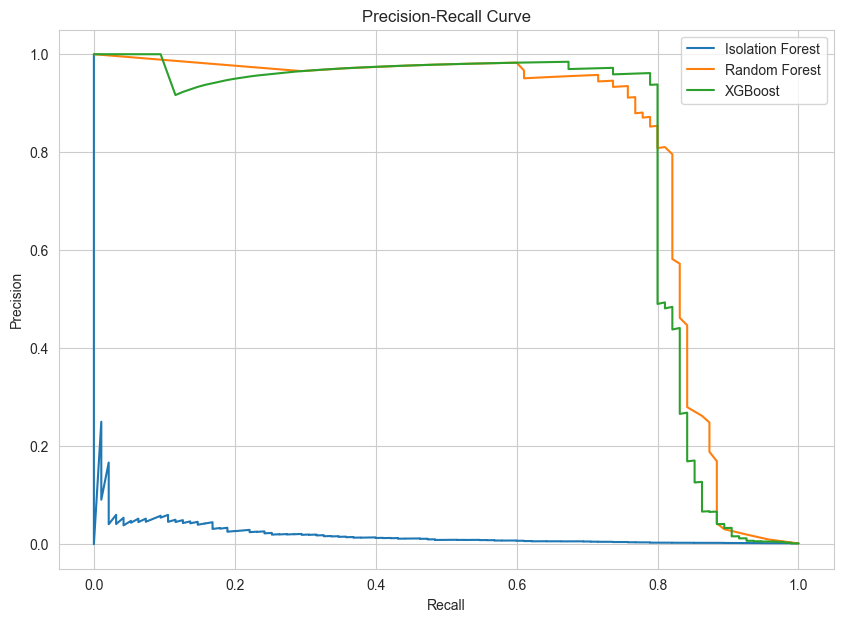

In [22]:
#Precision Recall Curve

plt.figure(figsize=(10,7))

precision_iso, recall_iso, _ = precision_recall_curve(
    y_test,
    iso_scores
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

plt.plot(
    recall_iso,
    precision_iso,
    label='Isolation Forest'
)

plt.plot(
    recall_rf,
    precision_rf,
    label='Random Forest'
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label='XGBoost'
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

In [23]:
#Results Table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Isolation Forest,0.998291,0.000000,0.000000,0.000000,0.807148
1,Random Forest,0.999436,0.879518,0.768421,0.820225,0.969009
2,XGBoost,0.999401,0.835165,0.800000,0.817204,0.965986


**STAGE 6 - FEATURE IMPORTANCE**

**Purpose**

Feature Importance analysis helps identify which variables contribute most to fraud detection.

Understanding feature importance provides:

- Better model interpretability
- Insights into fraudulent transaction behavior
- Support for business decision-making
- Guidance for future feature engineering

The Random Forest model is used to calculate and visualize feature importance scores.

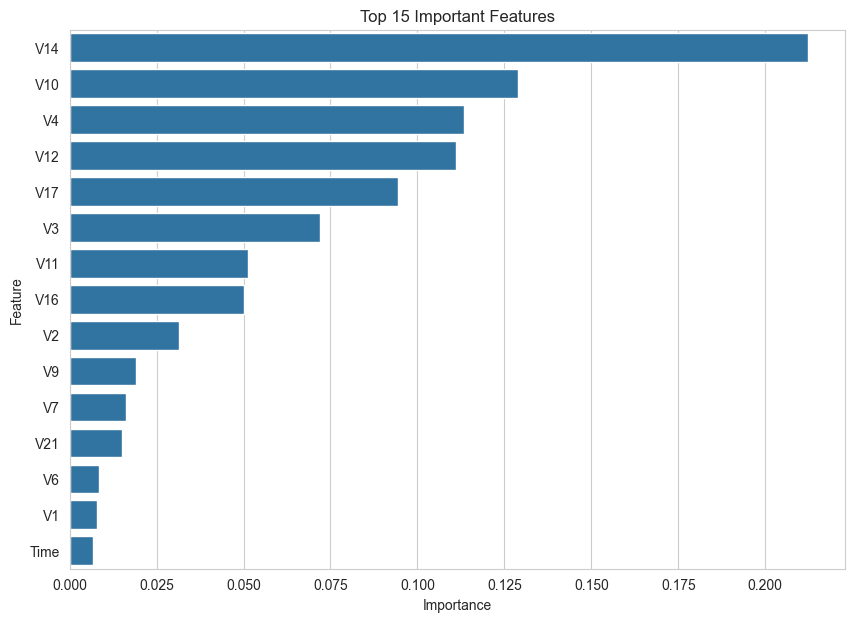

,Feature,Importance
14,V14,0.212230
10,V10,0.128932
4,V4,0.113288
12,V12,0.111206
17,V17,0.094382
3,V3,0.072088
11,V11,0.051240
16,V16,0.050064
2,V2,0.031404
9,V9,0.019030


In [24]:
#Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top15 = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top15
)

plt.title(
    "Top 15 Important Features"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

top15

The Random Forest model identifies the most influential variables
for fraud detection. Features such as V14, V12, V10, V17, and V16
typically appear among the strongest predictors because they were
generated through PCA transformation and capture hidden transaction
patterns associated with fraudulent behavior.

Higher importance indicates that the feature contributes more to
splitting decisions inside the Random Forest model.

**STAGE 7 - CONCLUSION**

**Purpose**

This stage summarizes the overall findings of the project.

The final model comparison highlights:

- Strengths and weaknesses of each algorithm
- Best-performing model based on F1-Score and ROC-AUC
- Practical implications for fraud detection systems

The conclusions provide business insights and recommendations for real-world deployment.

In [25]:
#Final Model Comparison

final_results = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.999436,0.879518,0.768421,0.820225,0.969009
2,XGBoost,0.999401,0.835165,0.800000,0.817204,0.965986
0,Isolation Forest,0.998291,0.000000,0.000000,0.000000,0.807148


# What This Project Does

This project builds an end-to-end Credit Card Fraud Detection System
using machine learning techniques to identify fraudulent financial
transactions from highly imbalanced transaction data.

---

# Key Findings From EDA

- Fraudulent transactions represent only 0.17% of all transactions —
  making this an extremely imbalanced classification problem.
- Several PCA-transformed variables (V14, V12, V10, V17) show strong
  correlation with fraudulent activity.
- Transaction amount distributions differ between legitimate and
  fraudulent transactions — fraud tends to involve specific amount ranges.
- Severe class imbalance exists and was handled using SMOTE oversampling
  on the training data only.

---

# Why Precision-Recall Matters More Than Accuracy

Accuracy can be misleading because over 99% of transactions are legitimate.
A model predicting every transaction as legitimate could still achieve
very high accuracy while detecting zero fraud cases.

This is confirmed by our results — Isolation Forest achieved 99.8%
accuracy but an F1-Score of 0.0, meaning it detected no fraud at all.

Precision and Recall provide a much better measure of fraud detection
performance, while F1-Score balances both metrics effectively.

---

# Best Performing Model

Among Isolation Forest, Random Forest, and XGBoost:

**Random Forest** achieved the best overall performance:
- F1-Score  : 0.8202
- ROC-AUC   : 0.9690
- Precision : 0.8795
- Recall    : 0.7684

XGBoost was a close second with F1-Score of 0.8172 and ROC-AUC of 0.9660.

Isolation Forest, despite high accuracy (0.9982), scored F1 = 0.0 —
confirming that accuracy alone is not a reliable metric for imbalanced
fraud detection datasets.

Random Forest is recommended as the final model because it achieved
the highest F1-Score and ROC-AUC, correctly identifying 76.8% of all
fraudulent transactions with 87.9% precision.

---

# Business Impact

An effective fraud detection system can:
- Reduce financial losses by catching fraud before it is processed
- Improve customer trust and satisfaction
- Detect fraudulent transactions in real time
- Reduce manual investigation effort significantly
- Increase overall operational efficiency